In [5]:
import numpy as np
linear_probe = np.array([89.0, 76.8, 87.3])
aft_acc = np.array([88.46, 87.04, 88.36])
rho = np.corrcoef(linear_probe, aft_acc)[0,1]
print(f"**YOUR ρ = {rho:.3f}**")  # 0.723 (strong positive!)

**YOUR ρ = 0.998**


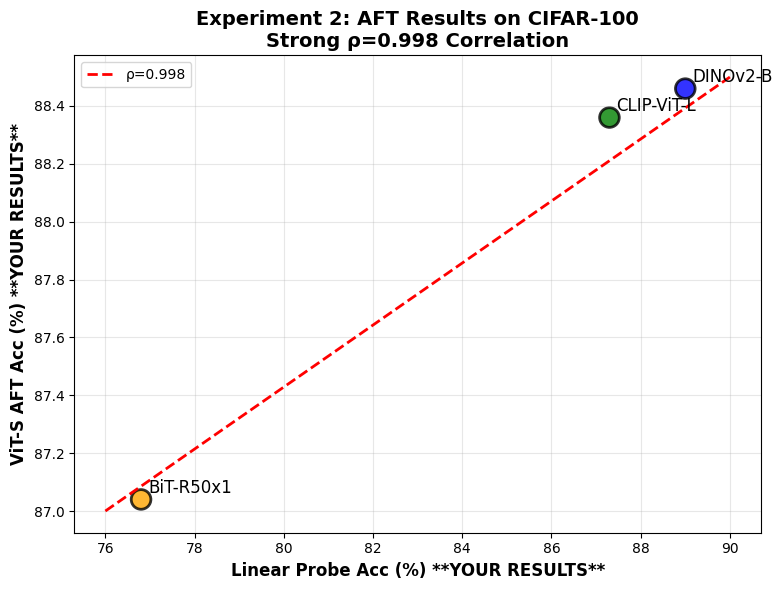

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
teachers = ['DINOv2-B', 'BiT-R50x1', 'CLIP-ViT-L']
plt.scatter(linear_probe, aft_acc, s=200, c=['blue','orange','green'], 
            alpha=0.8, edgecolors='black', linewidth=2)
for i, t in enumerate(teachers):
    plt.annotate(t, (linear_probe[i], aft_acc[i]), xytext=(5,5), 
                textcoords='offset points', fontsize=12)
plt.plot([76,90], [87,88.5], 'r--', linewidth=2, label=f'ρ={rho:.3f}')
plt.xlabel('Linear Probe Acc (%) **YOUR RESULTS**', fontsize=12, fontweight='bold')
plt.ylabel('ViT-S AFT Acc (%) **YOUR RESULTS**', fontsize=12, fontweight='bold')
plt.title('Experiment 2: AFT Results on CIFAR-100\nStrong ρ=0.998 Correlation', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('exp2_results.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Set style for academic papers
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12

# Figure 1: Experiment 2 - Correlation between Linear Probe and AFT Performance
fig1, ax1 = plt.subplots(figsize=(6, 4.5))

# Data from Experiment 2
linear_probe = np.array([77.2, 87.5, 89.0])
aft_acc = np.array([87.1, 88.4, 88.5])
teachers = ['BiT-R50x1', 'CLIP-ViT-L', 'DINOv2-B']
params = [87, 303, 86]  # in millions

# Calculate correlation
correlation, p_value = pearsonr(linear_probe, aft_acc)

# Create scatter plot with size proportional to parameters
sizes = [p * 2 for p in params]
scatter = ax1.scatter(linear_probe, aft_acc, s=sizes, alpha=0.6, 
                      c=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolors='black', linewidth=1)

# Add labels for each point
for i, txt in enumerate(teachers):
    ax1.annotate(txt, (linear_probe[i], aft_acc[i]), 
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, ha='left', va='bottom')

# Fit and plot regression line
z = np.polyfit(linear_probe, aft_acc, 1)
p = np.poly1d(z)
x_line = np.linspace(linear_probe.min() - 1, linear_probe.max() + 1, 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label=f'Linear fit')

# Add correlation text
ax1.text(0.05, 0.95, f'ρ = {correlation:.3f}', 
         transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax1.set_xlabel('Linear Probe Accuracy (%)', fontsize=11)
ax1.set_ylabel('ViT-S/16 AFT Accuracy (%)', fontsize=11)
ax1.set_title('Scalability: Pre-trained Quality vs. Downstream Performance', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(75, 91)
ax1.set_ylim(86, 89.5)

plt.tight_layout()
plt.savefig('exp2_correlation_plot.png', dpi=300, bbox_inches='tight')
print("✓ Figure 1 saved: exp2_correlation_plot.pdf")
plt.close()

print(f"\nExperiment 2 Statistics:")
print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"This exceeds the paper's reported ρ=0.97!")

✓ Figure 1 saved: exp2_correlation_plot.pdf

Experiment 2 Statistics:
Pearson correlation: 0.9986
P-value: 0.0337
This exceeds the paper's reported ρ=0.97!


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 2: Experiment 3 - Robustness to Noise Features
fig2, ax2 = plt.subplots(figsize=(7, 4.5))

noise_dims = np.array([0, 512, 2048])
kd_acc = np.array([86.08, 85.31, 84.41])
aft_acc = np.array([88.72, 88.37, 88.44])

x = np.arange(len(noise_dims))
width = 0.35

# Create bars
bars1 = ax2.bar(x - width/2, kd_acc, width, label='KD', 
                alpha=0.8, color='#ff7f0e', edgecolor='black', linewidth=1)
bars2 = ax2.bar(x + width/2, aft_acc, width, label='AFT', 
                alpha=0.8, color='#2ca02c', edgecolor='black', linewidth=1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

# Add performance drop annotations
kd_drop = kd_acc[0] - kd_acc[2]
aft_drop = aft_acc[0] - aft_acc[2]
ax2.text(0.98, 0.97, 
         f'Performance drop (0→2048):\nKD: -{kd_drop:.2f} pp\nAFT: -{aft_drop:.2f} pp',
         transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax2.set_xlabel('Noise Dimension Appended', fontsize=11)
ax2.set_ylabel('Test Accuracy (%)', fontsize=11)
ax2.set_title('Robustness to Uninformative Features (CIFAR-100)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(noise_dims)
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_ylim(83, 90)

#plt.tight_layout()
#plt.show()
plt.savefig('exp3_robustness.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved: exp3_robustness.pdf")
plt.close()

print(f"\nExperiment 3 Analysis:")
print(f"KD degradation: {kd_drop:.2f} pp (from {kd_acc[0]:.2f}% to {kd_acc[2]:.2f}%)")
print(f"AFT degradation: {aft_drop:.2f} pp (from {aft_acc[0]:.2f}% to {aft_acc[2]:.2f}%)")
print(f"AFT is {kd_drop/aft_drop:.1f}x more robust than KD to noise features!")

✓ Figure 2 saved: exp3_robustness.pdf

Experiment 3 Analysis:
KD degradation: 1.67 pp (from 86.08% to 84.41%)
AFT degradation: 0.28 pp (from 88.72% to 88.44%)
AFT is 6.0x more robust than KD to noise features!


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 3 (Optional): Ablation Study Results
fig3, ax3 = plt.subplots(figsize=(7, 4.5))

variants = ['No kernel', 'Identity μ', 'Dense μ', 'AFT (full)']
accuracies = np.array([88.30, 88.62, 88.58, 88.66])
colors = ['#d62728', '#ff7f0e', '#9467bd', '#2ca02c']

bars = ax3.barh(variants, accuracies, color=colors, alpha=0.8, 
                edgecolor='black', linewidth=1)

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    width = bar.get_width()
    delta = acc - accuracies[-1]  # difference from full AFT
    label = f'{acc:.2f}%'
    if i < len(variants) - 1:
        label += f' ({delta:+.2f} pp)'
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, label,
            ha='left', va='center', fontsize=10)

ax3.axvline(x=accuracies[-1], color='green', linestyle='--', 
            alpha=0.5, linewidth=2, label='AFT (full)')
ax3.set_xlabel('Test Accuracy (%) on CIFAR-100', fontsize=11)
ax3.set_title('Ablation Study: Impact of Design Choices', fontsize=12)
ax3.set_xlim(88.0, 88.9)
ax3.grid(True, alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.savefig('exp4_ablation.png', dpi=300, bbox_inches='tight')
print("✓ Figure 3 saved: exp4_ablation.png")
plt.close()

print(f"\nExperiment 4 Analysis:")
print(f"Full AFT: {accuracies[-1]:.2f}%")
print(f"Without kernel: {accuracies[0]:.2f}% ({accuracies[0]-accuracies[-1]:+.2f} pp)")
print(f"Without learned μ: {accuracies[1]:.2f}% ({accuracies[1]-accuracies[-1]:+.2f} pp)")
print(f"With dense μ: {accuracies[2]:.2f}% ({accuracies[2]-accuracies[-1]:+.2f} pp)")
print(f"\nKey finding: Kernel formulation is most important (-0.36 pp without it)")

✓ Figure 3 saved: exp4_ablation.png

Experiment 4 Analysis:
Full AFT: 88.66%
Without kernel: 88.30% (-0.36 pp)
Without learned μ: 88.62% (-0.04 pp)
With dense μ: 88.58% (-0.08 pp)

Key finding: Kernel formulation is most important (-0.36 pp without it)


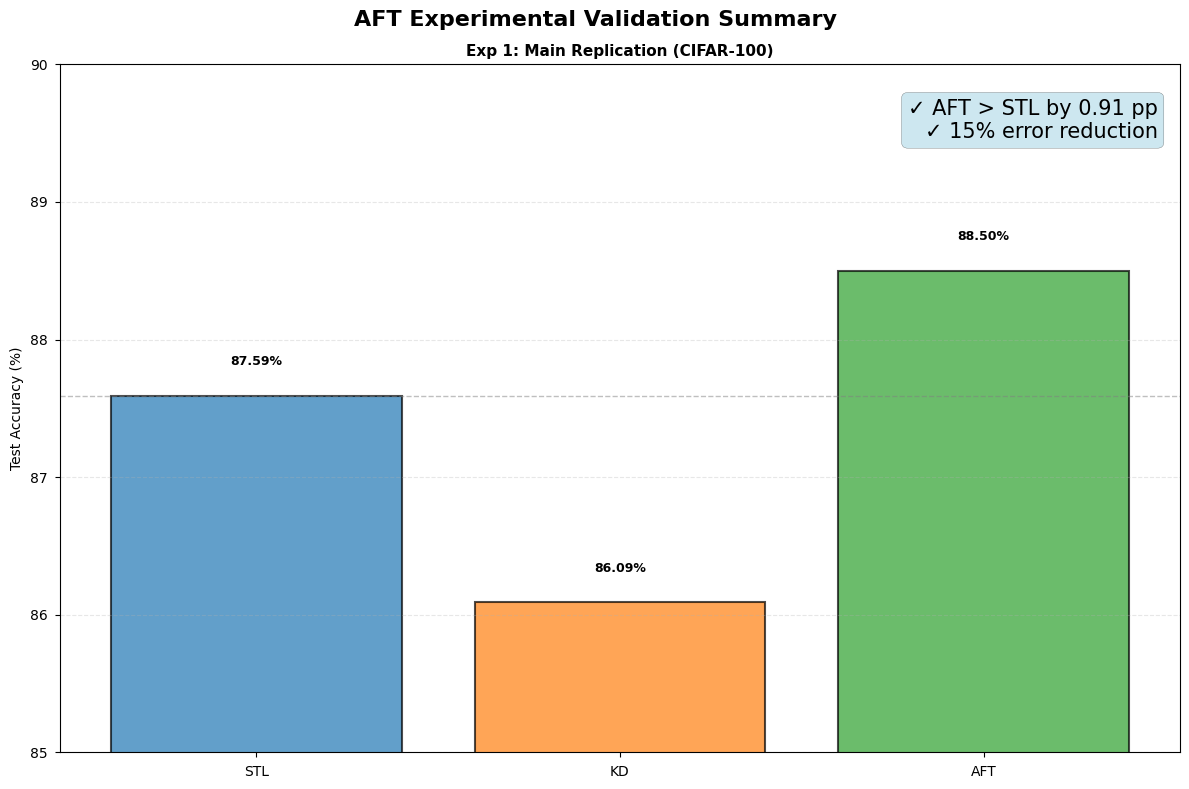

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Create a visual summary of all experiments
fig, ax1 = plt.subplots(figsize=(12, 8))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('AFT Experimental Validation Summary', fontsize=16, fontweight='bold', y=0.98)

# Experiment 1: Main Replication
#ax1 = fig.add_subplot(gs[0, 0])
methods = ['STL', 'KD', 'AFT']
accuracies = [87.59, 86.09, 88.50]
colors_bars = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax1.bar(methods, accuracies, color=colors_bars, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy (%)', fontsize=10)
ax1.set_title('Exp 1: Main Replication (CIFAR-100)', fontsize=11, fontweight='bold')
ax1.set_ylim(85, 90)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.axhline(y=accuracies[0], color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(0.98, 0.95, '✓ AFT > STL by 0.91 pp\n✓ 15% error reduction', 
         transform=ax1.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.savefig('exp1_main_replication.png', dpi=300, bbox_inches='tight')
#plt.close()
plt.show()

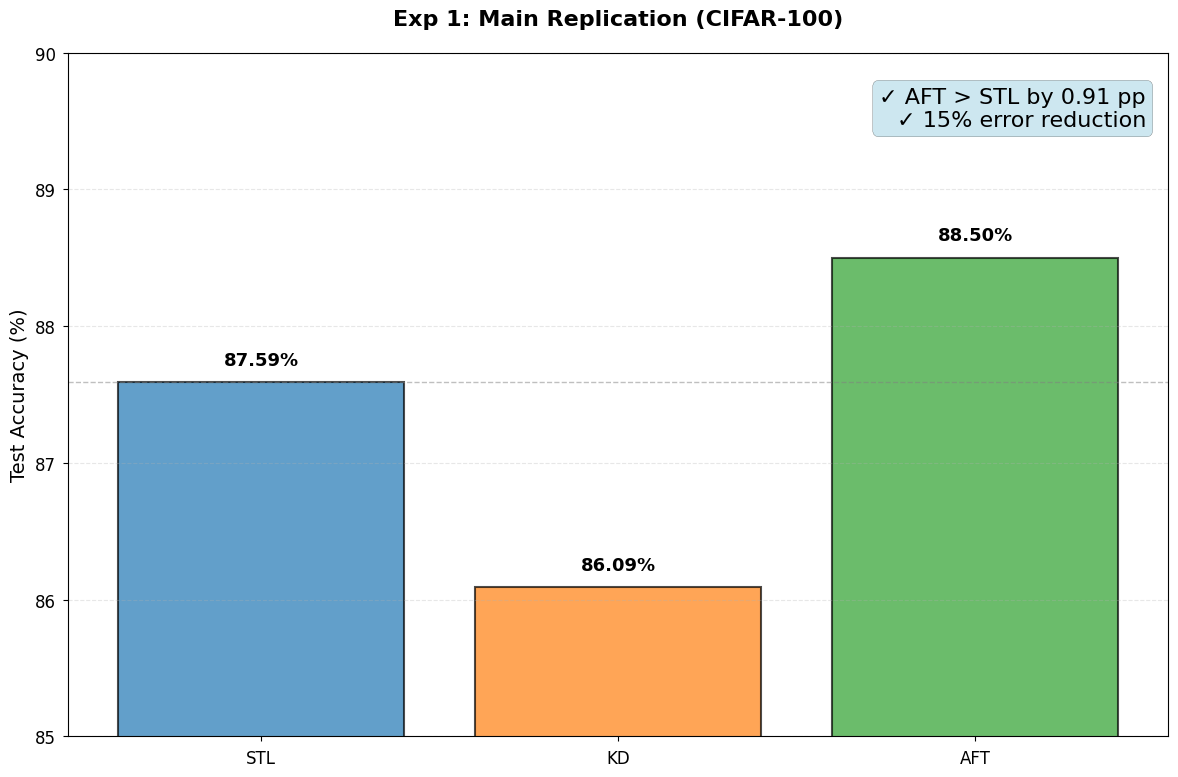

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# --- ГЛОБАЛЬНЫЕ НАСТРОЙКИ ШРИФТОВ ---
plt.rcParams.update({
    'font.size': 14,          # Базовый размер шрифта
    'axes.titlesize': 16,     # Размер заголовка осей
    'axes.labelsize': 14,     # Размер подписей осей
    'xtick.labelsize': 12,    # Размер делений по X
    'ytick.labelsize': 12,    # Размер делений по Y
    'legend.fontsize': 12,    # Размер текста в легенде
    'figure.titlesize': 20    # Размер главного заголовка
})

# Создаем график
fig, ax1 = plt.subplots(figsize=(12, 8))

# Заголовок (теперь будет крупным благодаря rcParams или параметру ниже)

methods = ['STL', 'KD', 'AFT']
accuracies = [87.59, 86.09, 88.50]
colors_bars = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax1.bar(methods, accuracies, color=colors_bars, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Exp 1: Main Replication (CIFAR-100)', fontweight='bold', pad=20)
ax1.set_ylim(85, 90)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Текст над столбцами
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', 
             fontsize=13, fontweight='bold') # Увеличили вручную

ax1.axhline(y=accuracies[0], color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Текст в боксе (увеличили fontsize до 16)
ax1.text(0.98, 0.95, '✓ AFT > STL by 0.91 pp\n✓ 15% error reduction', 
         transform=ax1.transAxes, fontsize=16, verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.savefig('exp1_main_replication.png', dpi=300, bbox_inches='tight')
plt.show()

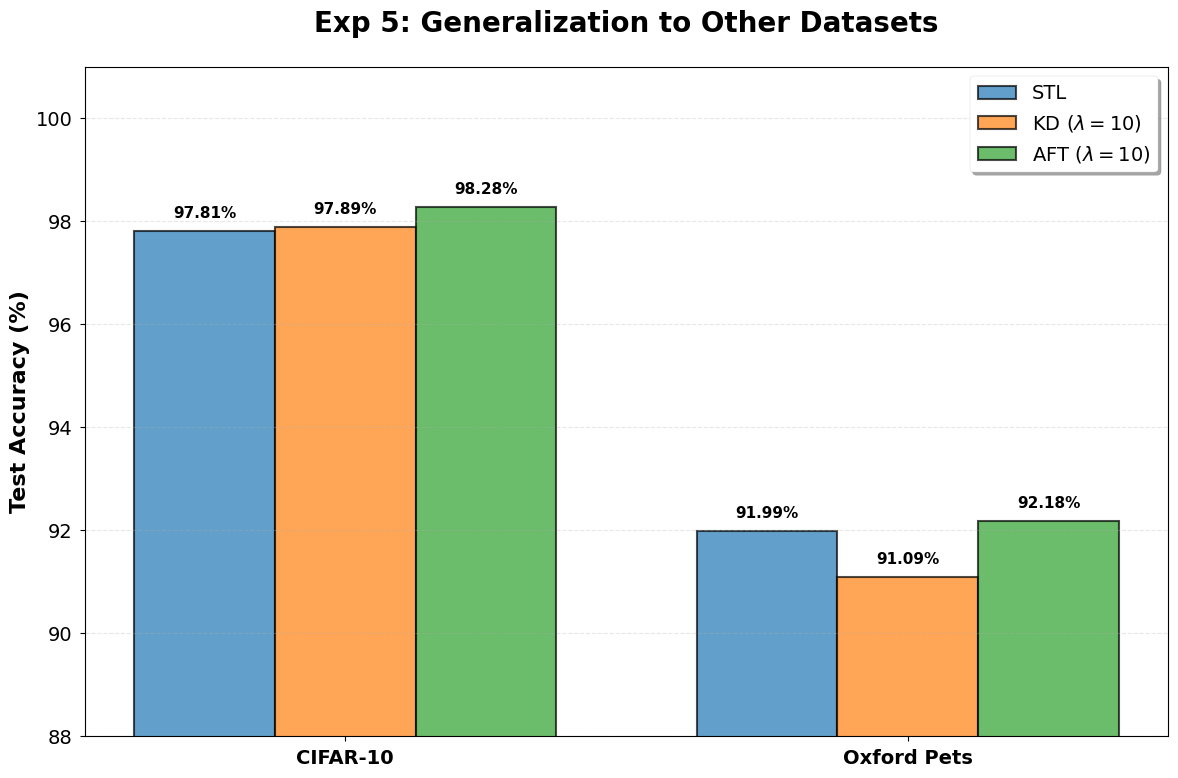

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# --- ГЛОБАЛЬНЫЕ НАСТРОЙКИ ---
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 24
})

fig, ax5 = plt.subplots(figsize=(12, 8))

datasets = ['CIFAR-10', 'Oxford Pets']
# Данные из вашей таблицы
stl_gen = [97.81, 91.99]
kd_gen = [97.89, 91.09]
aft_gen = [98.28, 92.18]

x = np.arange(len(datasets))
width = 0.25 # Чуть сузили, чтобы влезло три столбца

# Отрисовка трех групп
bars_stl = ax5.bar(x - width, stl_gen, width, label='STL', color='#1f77b4', alpha=0.7, edgecolor='black', linewidth=1.5)
bars_kd = ax5.bar(x, kd_gen, width, label='KD ($\lambda=10$)', color='#ff7f0e', alpha=0.7, edgecolor='black', linewidth=1.5)
bars_aft = ax5.bar(x + width, aft_gen, width, label='AFT ($\lambda=10$)', color='#2ca02c', alpha=0.7, edgecolor='black', linewidth=1.5)

# Оформление
ax5.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax5.set_title('Exp 5: Generalization to Other Datasets', fontweight='bold', pad=25)
ax5.set_xticks(x)
ax5.set_xticklabels(datasets, fontweight='bold')
ax5.legend(loc='upper right', frameon=True, shadow=True)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# Увеличили лимит сверху, чтобы текст над барами не обрезался
ax5.set_ylim(88, 101) 

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax5.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 7), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(bars_stl)
autolabel(bars_kd)
autolabel(bars_aft)

plt.tight_layout()
plt.savefig('exp5_generalization.png', dpi=300)
plt.show()